# `LogarithmicScheduler`

This notebook provides an empirical demonstration of the expected behavior of a `LogarithmicScheduler`. Its purpose is to make the module's scheduling behavior observable in a simple setting in which it can be studied in isolation, rather than to exhaustively validate every implementation detail.

The capability examined is logarithmic scheduling across depth. A `LogarithmicScheduler` changes its value logarithmically as depth increases, while respecting the configured lower and upper bounds.

## Conceptual Overview

A `LogarithmicScheduler` defines a logarithmic relationship between depth and scheduled value. For a scale $a$, offset $o$, and intercept $b$, the unconstrained value at depth $d$ is

$$
S(d)=a\ln(d+o)+b.
$$

The scale determines the magnitude of the logarithmic component, the offset shifts its input along the depth axis, and the intercept shifts the resulting relationship vertically. The configured minimum and maximum values bound the schedule within the permitted range.

### Scope of the demonstration

The experiment evaluates a `LogarithmicScheduler` over a finite range of depths and visualizes the resulting schedule.

In [1]:
import matplotlib.pyplot as plt

from jacinta.utils.schedulers import LogarithmicScheduler

## Configuration

The parameters below are chosen to make the relevant behavior visible, but they should not be interpreted as general-purpose defaults.

`SCALE = 140` defines the magnitude of the logarithmic component.

`OFFSET = 10` shifts the logarithmic input so that the schedule is defined from depth zero.

`INTERCEPT = -320` shifts the logarithmic relationship vertically.

`MIN_VALUE = 0` and `MAX_VALUE = 1000` define the lower and upper bounds of the schedule.

`MAX_DEPTH = 10000` determines the range over which the schedule is visualized. It does not affect the scheduler itself.

In [2]:
# hyperparameters
SCALE = 140
OFFSET = 10
INTERCEPT = -320
MIN_VALUE = 0
MAX_VALUE = 1000

# plot parameters
MAX_DEPTH = 10000

## Visualization Utilities

The `LogarithmicScheduler` can be evaluated directly at a requested depth. The following helper exposes that mapping for visualization.

`plot_scheduler()` evaluates the scheduler at every depth from zero through `MAX_DEPTH` and plots the resulting schedule. This provides a direct view of its behavior across the displayed range.

In [3]:
def plot_scheduler(
    ax: plt.Axes,
    scheduler: LogarithmicScheduler,
) -> None:
    """
    Plot a scheduler.

    Args:
        ax (plt.Axes): The axes to plot on.
        scheduler (LogarithmicScheduler): The scheduler to plot.
    """
    # evaluate the scheduler
    depths = list(range(MAX_DEPTH + 1))
    values = [scheduler(depth) for depth in depths]
    # plot the scheduler
    ax.plot(depths, values)
    ax.set_xlim(0, MAX_DEPTH)
    ax.set_xlabel("Depth")
    ax.set_ylabel("Value")
    ax.set_title(
        f"Logarithmic Scheduler "
        f"(scale={SCALE}, offset={OFFSET}, intercept={INTERCEPT}, "
        f"min_value={MIN_VALUE}, max_value={MAX_VALUE})"
    )
    ax.grid(visible=True, alpha=0.3)
    return

## Evaluation

The plot shows the scheduled value increasing from approximately `2.36` at depth `0` to approximately `969.59` at depth `10000`. The increase is initially steep and becomes progressively more gradual as depth grows, reflecting a decreasing rate of change throughout the displayed range.

The curved trajectory confirms that equal increases in depth produce increasingly smaller changes in the scheduled value while the schedule remains within its configured bounds.

In [4]:
# initialize a LogarithmicScheduler
scheduler = LogarithmicScheduler(
    scale=SCALE,
    offset=OFFSET,
    intercept=INTERCEPT,
    min_value=MIN_VALUE,
    max_value=MAX_VALUE,
)

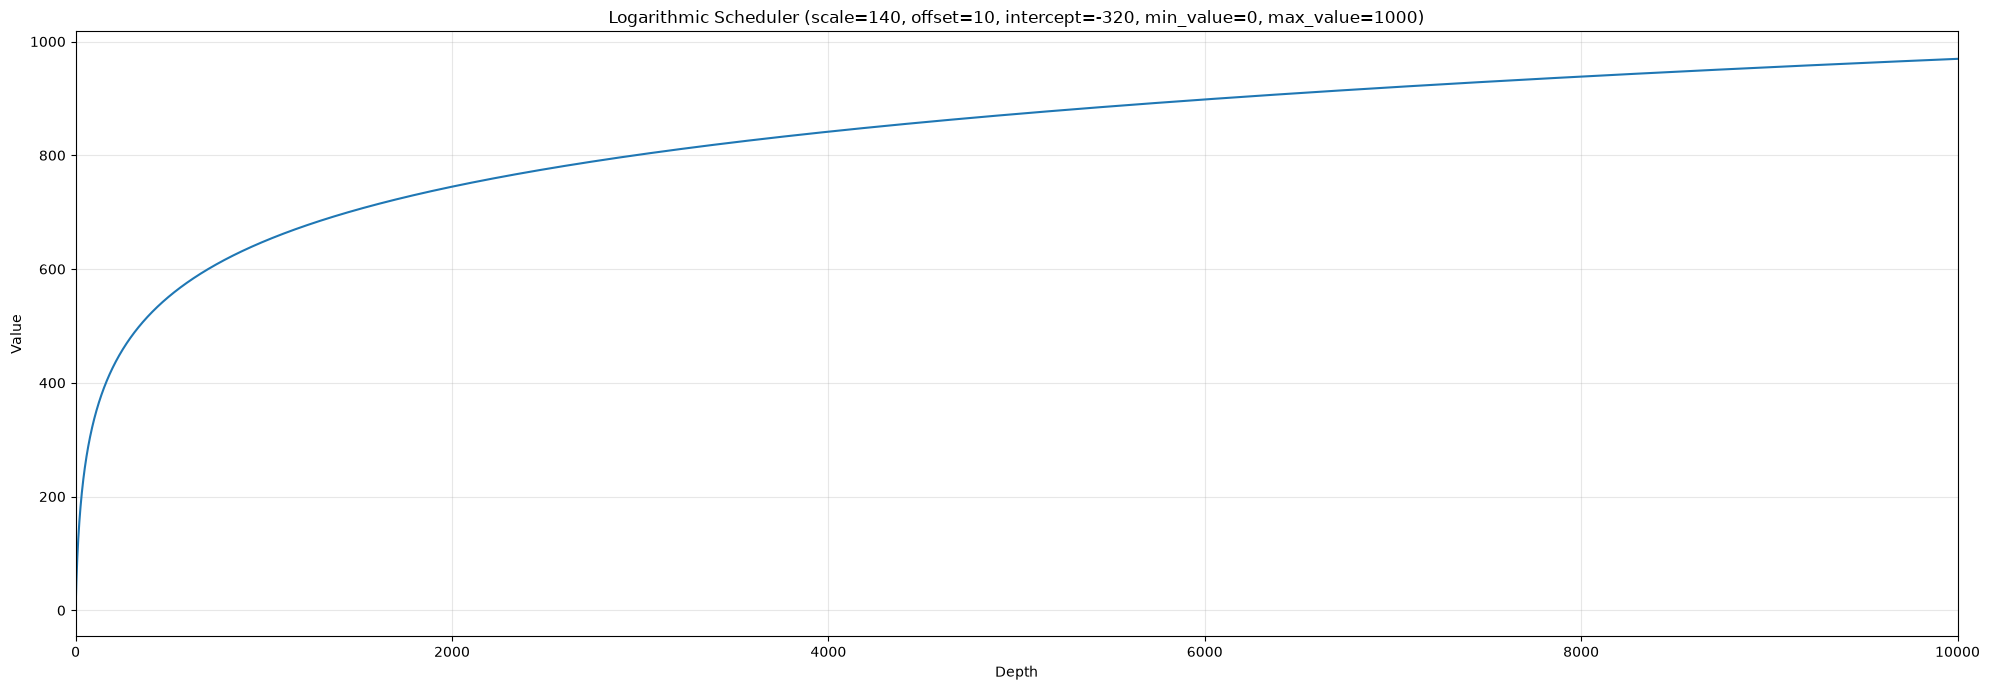

In [5]:
# plot the scheduler
fig, ax = plt.subplots(figsize=(20, 7))
plot_scheduler(ax, scheduler)
fig.tight_layout()
plt.show()

## Conclusions

This playground provides an empirical view of how a `LogarithmicScheduler` maps depth to a value whose rate of change decreases with depth. The configured scale, offset, and intercept determine the shape and position of the logarithmic relationship, while the minimum and maximum values constrain the resulting schedule.

Examined in isolation, the module exhibits its intended behavior: it implements a bounded logarithmic scheduling strategy in which the scheduled value grows at a decreasing rate across depth.